# ENTREGA FINAL - VISUALIZACIÓN OBJETIVO SECUNDARIO OS03
## OS03 – prosperidad y productividad en Madrid. 
#### Caracterizar y explorar asociaciones entre exposición al ruido y prosperidad (nivel de ingresos).

### Se analizan asociaciones espaciales y temporales entre exposición al ruido e indicadores de renta/prosperidad, utilizando indicadores de renta y niveles acñusticos.
Para ello se propone el uso de representaciones, análisis y correlaciones.

Puntos clave que guían las visualizaciones:
* No causalidad → asociación / correlación
* Uso combinado de:
* * Enfoque espacial (CP / barrio cuando sea posible)
* * Enfoque temporal (evolución anual)

DATOS UTILIZADOS:
* df_09* – INE, Atlas de Distribución de Renta de los Hogares (ADRH): cod_postal / seccion_censal / barrio, renta_media, renta_mediana, año
* Ruido:
* * df_02_cont_acustic → Ln, LAeq, por estación y año.
* * df_02_estac → información de las estaciones de medición
* * df_01_daily → agregados temporales
* Geografía: códigos postales / barrios usados en OS01 (df_actividad_cp) derivados de df_06_locales
* Normativa (contexto): df_03_noise_lim 

Para el análisis del OS03  se realizan las siguientes visualizaciones asociadas:

Visualización - Rol en OS03
* OS03‑01 Renta y ruido nocturno: relación temporal en Madrid -> Contexto temporal macro
* OS03‑02 Asociación entre ruido nocturno y renta media (análisis anual) -> Asociación cuantitativa
* OS03‑03 Distribución de renta según nivel de exposición acústica -> Comparación distributiva
* OS03‑04 Evolución conjunta de ruido, renta y normativa (contexto) -> Contexto normativo


No se incluye una visualización espacial por código postal en el OS03, ya que los datos de renta disponibles (INE ADRH) se encuentran agregados a nivel municipal y no permiten una desagregación intraurbana coherente. La inclusión de un mapa a escala de código postal introduciría una falsa diferenciación espacial de los ingresos, por lo que se ha optado por un análisis temporal y agregado consistente con la escala real de los datos.

* PREPRARACIÓN DE ENTORNO

In [3]:
import altair as alt

# Se desactiva vegafusion
alt.data_transformers.enable("default", max_rows=None)

# Renderer compatible con JupyterLab / Anaconda
alt.renderers.enable("mimetype")

RendererRegistry.enable('mimetype')

In [4]:
import pandas as pd
import altair as alt
import requests
import reverse_geocoder as rg
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.decomposition import PCA
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import fcluster
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import unicodedata



pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

* CARGA DE DATOS PREPROCESADOS

In [5]:
# Carga los datos PREPROCESADOS disponibles en Kaggle. En la cuenta del alumno raquelahdo/ruido-datasets-procesados
# https://www.kaggle.com/datasets/raquelahdo/ruido-datasets-procesados

file_path_01_ruido_diario = "df_01_Ruido_diario_acumulado_processed.csv"
file_path_01_daily = "df_01_daily_processed.csv"
file_path_01_daily_plot = "df_01_daily_plot.csv"
file_path_02_cont_acustica = "df_02_contaminacion_acustica_processed.csv"
file_path_02_estac = "df_02_estacion_processed.csv"
file_path_03_noise_lim = "df_03_noise_limit_processed.csv"
file_path_05_est_ac_proc = "df_05_estaciones-acusticas_processed.csv"
# file_path_06_locales = "df_06_locales_terrazas_processed.csv"
# file_path_07_Mad_Q_vida = "df_07_Madrid-calidad-vida_processed.csv"
# file_path_07_Q_vida = "df_07_calidad-vida_processed.csv"
# file_path_07_evo_Q_vida = "df_07_evolucion-calidad-vida_processed.csv"
# file_path_07_evo_long_Q_vida = "df_07_evolucion-long-calidad-vida_processed.csv"
# file_path_07_fin_Q_vida_proc = "df_07_final-calidad-vida_processed.csv"
file_path_09_renta = "df_09_reduced_distribucion-renta_processed.csv"
file_path_os01_actividad_cp = "df_actividad_cp.csv"
file_path_os01_actividad_barrio = "df_actividad_barrio.csv"


df_01_ruido_diario = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_01_ruido_diario,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_01_daily = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_01_daily,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_01_daily_plot = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_01_daily_plot,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_02_cont_acustic = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_02_cont_acustica,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_02_estac = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_02_estac,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_03_noise_lim = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_03_noise_lim,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_05_est_ac = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_05_est_ac_proc,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_06_locales = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_06_locales,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_07_Mad_Q_vida = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_07_Mad_Q_vida,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_07_Q_vida = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_07_Q_vida,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_07_evo_Q_vida = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_07_evo_Q_vida,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_07_evo_long_Q_vida = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_07_evo_long_Q_vida,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_07_fin_Q_vida_proc = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_07_fin_Q_vida_proc,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_09_renta = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_09_renta,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_os01_actividad_cp = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_os01_actividad_cp,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_os01_actividad_barrio = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_os01_actividad_barrio,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )


In [6]:
df_01_ruido_diario.head()

,NMT,year,month,day,periodo,laeq,l1,l10,l50,l90,l99,fecha,periodo_desc,mes_nombre,year_month,week,month_name
0,3,2014,1,1,D,57.4,66.6,61.1,54.3,49.1,45.0,2014-01-01,Diurno,Enero,2014-01,1,Enero
1,30,2014,1,1,D,55.6,64.7,59.2,51.9,45.9,43.5,2014-01-01,Diurno,Enero,2014-01,1,Enero
2,29,2014,1,1,T,57.2,67.4,62.1,49.0,36.6,29.8,2014-01-01,Total,Enero,2014-01,1,Enero
3,29,2014,1,1,N,55.0,66.7,57.4,41.5,30.9,29.2,2014-01-01,Nocturno,Enero,2014-01,1,Enero
4,29,2014,1,1,E,57.4,67.4,62.5,50.2,41.7,36.7,2014-01-01,Vespertino,Enero,2014-01,1,Enero


In [7]:
df_01_daily.head()

,fecha,periodo,laeq
0,2014-01-01,D,60.644
1,2014-01-01,E,61.176
2,2014-01-01,N,68.928
3,2014-01-01,T,66.156
4,2014-01-02,D,63.608


In [8]:
df_01_daily_plot.head()

,fecha,NMT,laeq
0,2014-01-01,3,61.050
1,2014-01-01,4,70.700
2,2014-01-01,5,64.475
3,2014-01-01,8,68.075
4,2014-01-01,10,64.450


In [9]:
df_02_cont_acustic.head()

,estacion,nombre,year,month,ld,le,ln,laeq,l1,l10,l50,l90,l99,fecha,mes_nombre,year_month,month_name
0,RF-19,Alto de Extremadura,1998,9,NaN,NaN,NaN,63.0,72.4,66.3,59.3,51.4,47.0,1998-09-01,Septiembre,1998-09,Septiembre
1,RF-16,Arturo Soria,1998,9,NaN,NaN,NaN,59.5,67.8,61.6,56.0,45.3,39.1,1998-09-01,Septiembre,1998-09,Septiembre
2,RF-14,Plaza Elíptica,1998,9,NaN,NaN,NaN,67.3,75.3,69.8,64.3,56.7,50.0,1998-09-01,Septiembre,1998-09,Septiembre
3,RF-11,Ramón y Cajal,1998,10,NaN,NaN,NaN,70.3,77.2,72.9,68.8,56.8,46.3,1998-10-01,Octubre,1998-10,Octubre
4,RF-14,Plaza Elíptica,1998,10,NaN,NaN,NaN,68.0,75.8,70.2,64.6,56.8,49.8,1998-10-01,Octubre,1998-10,Octubre


In [10]:
df_02_estac.head()

,estacion,laeq
0,RF-01,67.753311
1,RF-02,68.547328
2,RF-03,62.579321
3,RF-04,65.502980
4,RF-05,61.708411


In [11]:
df_03_noise_lim.head()

,noiselimitreportid_identifier,noisesource,limitvaluedefined,status,areatype,noiselevelindicator,limitvalue,explanation,limitvaluedefined_bool,noiselevel
0,LR_ES_00_01,allsources,yes,inforce,hospital,lday,60.0,This is not a limit value but rather an Acoust...,True,day
1,LR_ES_00_01,allsources,yes,inforce,hospital,levening,60.0,This is not a limit value but rather an Acoust...,True,evening
2,LR_ES_00_01,allsources,yes,inforce,hospital,lnight,50.0,This is not a limit value but rather an Acoust...,True,night
3,LR_ES_00_01,allsources,yes,inforce,school,lday,60.0,This is not a limit value but rather an Acoust...,True,day
4,LR_ES_00_01,allsources,yes,inforce,school,levening,60.0,This is not a limit value but rather an Acoust...,True,evening


In [12]:
df_05_est_ac.head()

,estacion,nombre,ubicacion,distrito,barrio,longitud,latitud,utm_x,utm_y,altitud,fecha_alta
0,RF-01,Paseo de Recoletos,Frente al n23 del Paseo de Recoletos,Centro,Justicia,-3.691877,40.422599,441307,4474893,648,2011-03-07
1,RF-02,Carlos V,"Plaza del Emperador Carlos V, junto al n1 del ...",Retiro,Jerónimos,-3.691509,40.409121,441327,4473397,629,1998-12-01
2,RF-03,Plaza del Carmen,Plaza del Carmen frente al n3 de la Calle de l...,Centro,Sol,-3.703175,40.419251,440346,4474529,657,1999-11-01
3,RF-04,Plaza de España,Frente al n18 de la Plaza de España,Moncloa - Aravaca,Argüelles,-3.712253,40.424005,439580,4475063,637,1998-12-01
4,RF-05,Barrio del Pilar,Parque de La Vaguada semiesquina de Avenida Mo...,Fuencarral - El Pardo,Pilar,-3.711543,40.478197,439688,4481078,673,1999-06-07


In [ ]:
# df_06_locales.head()

In [ ]:
# df_07_Mad_Q_vida.head()

In [ ]:
# df_07_Q_vida.head()

In [ ]:
# df_07_evo_Q_vida.head()

In [ ]:
# df_07_evo_long_Q_vida.head()

In [ ]:
# df_07_fin_Q_vida_proc.head()

In [13]:
df_09_renta.head()

,secciones,periodo,municipio_codigo,municipio_nombre,renta_media
0,"2800401001 Álamo, El sección 01001",2018,28004,"Álamo, El",11.75
1,"2800401001 Álamo, El sección 01001",2019,28004,"Álamo, El",14.00
2,"2800401001 Álamo, El sección 01001",2020,28004,"Álamo, El",11.40
3,"2800401001 Álamo, El sección 01001",2021,28004,"Álamo, El",22.80
4,"2800401001 Álamo, El sección 01001",2022,28004,"Álamo, El",20.90


In [14]:
df_os01_actividad_cp.head()

,cod_postal_local,hora_cierre_media,num_locales,num_terrazas
0,28001.0,2.391304,5467,111
1,28002.0,1.340000,4873,159
2,28003.0,2.857143,4053,190
3,28004.0,1.512821,6274,151
4,28005.0,1.806122,5675,310


In [15]:
df_os01_actividad_barrio.head()

,barrio,hora_cierre_media,num_locales,num_terrazas
0,ABRANTES,15.870089,112,5
1,ACACIAS,16.429717,318,27
2,ADELFAS,18.316111,90,4
3,AEROPUERTO,9.560606,121,0
4,ALAMEDA DE OSUNA,15.987083,80,4


Los datos de renta proceden del Atlas de Distribución de Renta de los Hogares (INE) y están originalmente disponibles a nivel de sección censal. Para garantizar la coherencia espacial con los datos acústicos, la renta media se agregó a nivel municipal y anual, obteniendo una medida sintética comparable con los niveles de ruido nocturno.

In [16]:
#Creamos df_renta_municipio que es la renta media agregada a nivel MUNICIPAL y AÑO,
#lista para cruzarse con el ruido acústico.
#Se obtiene a partir de df_09_renta, con dos pasos:
# * Agregar por municipio y año
# * Eliminar la dimensión de sección censal, que no es compatible con ruido

# Se hace la media de las secciones censales del municipio
# Se obtiene una sola renta media por municipio y año

 #El ruido acústico está disponible a nivel municipal
# * Promediar secciones es práctica estándar en análisis socioeconómico
# * Es coherente con el enfoque descriptivo y no causal de OS03
# * Evita mezclar escalas incompatibles

df_renta_municipio = (
    df_09_renta.rename(columns={"periodo": "año"})
    .groupby( ["municipio_codigo", "municipio_nombre", "año"], as_index=False )
    .agg(renta_media=("renta_media", "mean"))
)

df_renta_municipio.head()

,municipio_codigo,municipio_nombre,año,renta_media
0,28004,"Álamo, El",2015,18.333333
1,28004,"Álamo, El",2016,18.333333
2,28004,"Álamo, El",2017,24.000000
3,28004,"Álamo, El",2018,15.000000
4,28004,"Álamo, El",2019,13.500000


In [17]:
df_os01_actividad_cp.head()

,cod_postal_local,hora_cierre_media,num_locales,num_terrazas
0,28001.0,2.391304,5467,111
1,28002.0,1.340000,4873,159
2,28003.0,2.857143,4053,190
3,28004.0,1.512821,6274,151
4,28005.0,1.806122,5675,310


In [18]:
df_os01_actividad_barrio.head()

,barrio,hora_cierre_media,num_locales,num_terrazas
0,ABRANTES,15.870089,112,5
1,ACACIAS,16.429717,318,27
2,ADELFAS,18.316111,90,4
3,AEROPUERTO,9.560606,121,0
4,ALAMEDA DE OSUNA,15.987083,80,4


Los datos acústicos disponibles no incluyen información territorial directa a nivel municipal, por lo que el análisis del OS03 se realiza mediante agregaciones anuales globales. Esta aproximación permite explorar asociaciones descriptivas entre la evolución del ruido nocturno medio y los indicadores de renta, manteniendo la coherencia metodológica sin introducir supuestos espaciales no soportados por los datos.

El análisis del OS03 a nivel de código postal se restringe al municipio de Madrid y se basa en la agregación de la renta procedente de secciones censales a códigos postales, con el objetivo de explorar asociaciones descriptivas entre prosperidad económica y exposición al ruido. Dada la naturaleza agregada de los datos y la ausencia de correspondencias directas, los resultados deben interpretarse como patrones socioambientales exploratorios, sin inferir relaciones causales.


### Visualizaciones OS03 REPRESENTATIVAS

El OS03 analiza la relación entre prosperidad económica y exposición acústica en Madrid, combinando enfoques temporales y espaciales. A partir de indicadores de renta y niveles de ruido nocturno, se exploran asociaciones y desigualdades sin establecer relaciones causales, incorporando además el contexto normativo en materia de salud ambiental.

### VISUALIZACIÓN OS03‑01 · Renta y ruido nocturno: relación temporal en Madrid

Objetivo: Explorar si la evolución de la prosperidad económica en Madrid se acompaña de cambios en la exposición al ruido nocturno a lo largo del tiempo.

Tipo de gráfico: Gráfico combinado de líneas (Líneas superpuestas con escalas independientes, claramente rotuladas)

Justificación: Visión macro y temporal, adecuada para OS03. Permite ver tendencias paralelas o divergentes. No requiere desagregación espacial (evita errores de escala).

Datos utilizados: 
* df_01_daily o df_02_cont_acustic → agregación anual de Ln o LAeq
* df_09 (INE ADRH) → renta media anual en Madrid


In [19]:
# Ruido: media anual de Ln en Madrid
# Usamos df_02_cont_acustic, que en tu notebook contiene: year, ln, estación (no necesaria aquí)

df_ruido_anual = (
    df_02_cont_acustic
    .dropna(subset=["ln"])
    .groupby("year", as_index=False)
    .agg(
        ln_medio=("ln", "mean")
    )
)

In [20]:
# Renta: renta media anual (INE ADRH)
# Del df_09 / df_09_renta_municipio (según nombre exacto en tu notebook), que contiene: año y renta_media

df_renta_anual = (
    df_renta_municipio
    .groupby("año", as_index=False)
    .agg(
        renta_media=("renta_media", "mean")
    )
    .rename(columns={"año": "year"})
)

df_os03_01 = (
    df_renta_anual
    .merge(df_ruido_anual, on="year", how="inner")
)


In [21]:
df_ruido_anual.head()

,year,ln_medio
0,2015,57.257097
1,2016,57.769086
2,2017,57.706486
3,2018,57.444355
4,2019,57.098922


In [22]:
df_renta_anual.head()

,year,renta_media
0,2015,22.121141
1,2016,21.563468
2,2017,12.372847
3,2018,19.775733
4,2019,19.020879


In [23]:
df_os03_01.head()

,year,renta_media,ln_medio
0,2015,22.121141,57.257097
1,2016,21.563468,57.769086
2,2017,12.372847,57.706486
3,2018,19.775733,57.444355
4,2019,19.020879,57.098922


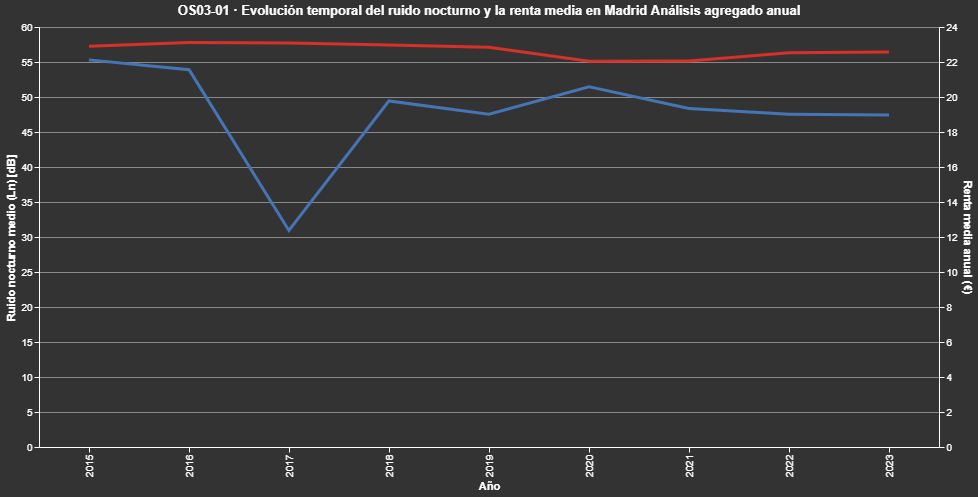

In [24]:
# =========================================================
# OS03-01 · Renta y ruido nocturno: relación temporal en Madrid
# =========================================================

# Línea de ruido nocturno (Ln)
line_ruido = (
    alt.Chart(df_os03_01)
    .mark_line(color="#d73027", strokeWidth=3)
    .encode(
        x=alt.X("year:O", title="Año"),
        y=alt.Y(
            "ln_medio:Q",
            title="Ruido nocturno medio (Ln) [dB]"
        ),
        tooltip=[
            alt.Tooltip("year:O", title="Año"),
            alt.Tooltip("ln_medio:Q", title="Ln medio [dB]", format=".2f")
        ]
    )
)

# Línea de renta media
line_renta = (
    alt.Chart(df_os03_01)
    .mark_line(color="#4575b4", strokeWidth=3)
    .encode(
        x=alt.X("year:O"),
        y=alt.Y(
            "renta_media:Q",
            title="Renta media anual (€)"
        ),
        tooltip=[
            alt.Tooltip("year:O", title="Año"),
            alt.Tooltip("renta_media:Q", title="Renta media (€)", format=",.0f")
        ]
    )
)

# Gráfico combinado
os03_01_chart = (
    alt.layer(line_ruido, line_renta)
    .resolve_scale(
        y="independent"   # 🔑 dos escalas Y visibles
    )
    .interactive()        # 🔑 zoom + pan
    .properties(
        width=900,
        height=420,
        title=(
            "OS03‑01 · Evolución temporal del ruido nocturno y la renta media en Madrid\n"
            "Análisis agregado anual"
        )
    )
)

os03_01_chart

La visualización OS03‑01 representa la evolución temporal conjunta del ruido nocturno medio y la renta media anual en Madrid. Cada indicador se muestra con su propia escala vertical, lo que permite comparar tendencias sin distorsionar la interpretación de los valores absolutos. La interactividad facilita la exploración detallada de periodos específicos.


### VISUALIZACIÓN OS03‑02 · Asociación entre ruido nocturno y renta media (análisis anual)

OBJETIVO: Analizar la relación estadística entre nivel de ruido nocturno y renta media, considerando la variación por año.

TIPO DE GRÁFICO: Diagrama de dispersión (scatter) con línea de tendencia

JUSTIFICACIÓN: Visualización clave de OS03. Permite identificar patrones de asociación (positiva, negativa o débil).
La línea de regresión refuerza la lectura sin implicar causalidad.

DATOS y datasets utilizados: 
* df_02_cont_acustic → Ln medio anual
* df_09 → renta_media
* df_os03_01 -> dataset calculado en la visualiación OS03-01. Incluye year, ln_medio, renta_media
* Integración a nivel ciudad‑año

Unidad de análisis: ciudad‑año (mismo nivel que OS03‑01):
* OS03‑01 → tendencia temporal (macro)
* OS03‑02 → asociación ruido‑prosperidad (clave analítica)
* Misma escala territorial y mismos datos. Coherencia en el análisis.

Variables:
* X → Ruido nocturno medio anual (Ln)
* Y → Renta media anual (€)
* Color → Año (para ver evolución temporal)

TIPO DE GRÁFICO: Scatter (puntos por año) + Línea de tendencia (regresión lineal) con interactividad (zoom + pan + tooltips)

No se busca causalidad. Se busca asociación y patrón global

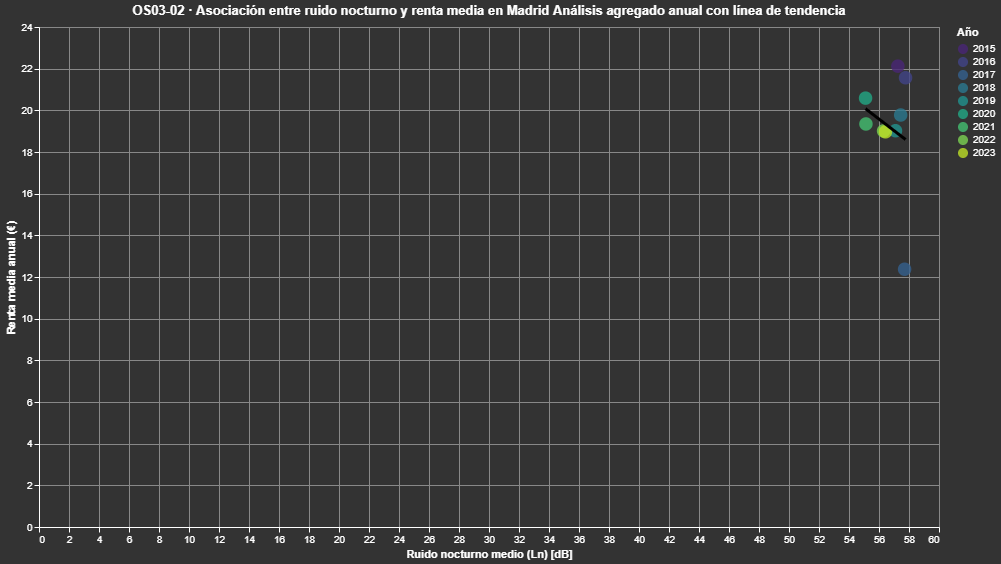

In [25]:
# =========================================================
# OS03‑02 · Asociación entre ruido nocturno y renta media
# =========================================================

os03_02_chart = (
    (
        # Scatter por año
        alt.Chart(df_os03_01)
        .mark_circle(size=180, opacity=0.8)
        .encode(
            x=alt.X(
                "ln_medio:Q",
                title="Ruido nocturno medio (Ln) [dB]"
            ),
            y=alt.Y(
                "renta_media:Q",
                title="Renta media anual (€)"
            ),
            color=alt.Color(
                "year:O",
                title="Año",
                scale=alt.Scale(scheme="viridis")
            ),
            tooltip=[
                alt.Tooltip("year:O", title="Año"),
                alt.Tooltip("ln_medio:Q", title="Ln medio [dB]", format=".2f"),
                alt.Tooltip("renta_media:Q", title="Renta media (€)", format=",.0f")
            ]
        )
        +
        # Línea de tendencia (regresión lineal)
        alt.Chart(df_os03_01)
        .transform_regression(
            "ln_medio",
            "renta_media",
            method="linear"
        )
        .mark_line(
            color="black",
            strokeWidth=3
        )
        .encode(
            x="ln_medio:Q",
            y="renta_media:Q"
        )
    )
    .interactive()
    .properties(
        width=900,
        height=500,
        title=(
            "OS03‑02 · Asociación entre ruido nocturno y renta media en Madrid\n"
            "Análisis agregado anual con línea de tendencia"
        )
    )
)

os03_02_chart

INTERPRETACIÓN: 
Cada punto representa un año

Eje X: nivel medio de ruido nocturno (Ln)
Eje Y: renta media anual (€)
Color: evolución temporal (años)
Línea negra: Es la línea de tendencia global (regresión lineal).

No implica causalidad, solo asociación

INTERPRETACIÓN VISUAL:
* Pendiente positiva → ruido y renta tienden a crecer juntos
* Pendiente negativa → mayor ruido asociado a menor renta
* Pendiente casi plana → relación débil o inexistente

La visualización OS03‑02 analiza la relación entre el nivel de ruido nocturno medio y la renta media anual en Madrid. Cada punto representa un año, mientras que la línea de tendencia resume el patrón global de asociación entre ambas variables. Esta aproximación permite explorar relaciones estadísticas sin establecer inferencias causales, en coherencia con el enfoque del OS03.

### VISUALIZACIÓN OS03‑03 · Renta según niveles de ruido nocturno (análisis por años)

OBJETIVO: Evaluar si existen diferencias sistemáticas de renta media entre periodos/años con distinto nivel de ruido nocturno en Madrid.

TIPO DE GRÁFICO: Boxplot 
* Eje X → nivel de ruido nocturno (bajo / medio / alto)
* Eje Y → renta media
* Cada observación = un año

JUSTIFICACIÓN: Resume la distribución de la renta bajo distintos niveles de ruido
Permite comparar: mediana, dispersión, valores extremos

Complementa perfectamente:
* OS03‑01 (evolución temporal)
* OS03‑02 (asociación continua)


PREPARACIÓN DE DATOS: 
* df_02_cont_acustic → ruido (ln, year)
* df_09_renta → renta (periodo, renta_media)

In [29]:
# Paso 1: ruido nocturno medio por año

df_ruido_anual = (
    df_02_cont_acustic
    .dropna(subset=["ln"])
    .groupby("year", as_index=False)
    .agg(
        ln_medio=("ln", "mean")
    )
)

df_ruido_anual.head()

,year,ln_medio
0,2015,57.257097
1,2016,57.769086
2,2017,57.706486
3,2018,57.444355
4,2019,57.098922


In [30]:
# Paso 2: renta media anual (Madrid)
df_renta_anual = (
    df_09_renta
    .groupby("periodo", as_index=False)
    .agg(
        renta_media=("renta_media", "mean")
    )
    .rename(columns={"periodo": "year"})
)

df_renta_anual.head()

,year,renta_media
0,2015,23.825265
1,2016,23.359292
2,2017,10.984895
3,2018,21.733797
4,2019,20.749759


In [31]:
# Paso 3: dataset integrado
df_os03_03 = (
    df_renta_anual
    .merge(df_ruido_anual, on="year", how="inner")
)

df_os03_03.head()

,year,renta_media,ln_medio
0,2015,23.825265,57.257097
1,2016,23.359292,57.769086
2,2017,10.984895,57.706486
3,2018,21.733797,57.444355
4,2019,20.749759,57.098922


In [32]:
# Paso 4: categorización del ruido (bajo / medio / alto)
# Se utilizan terciles, criterio estadístico estándar.


df_os03_03["nivel_ruido"] = pd.qcut(
    df_os03_03["ln_medio"],
    q=3,
    labels=["Bajo", "Medio", "Alto"]
)

df_os03_03.head()

,year,renta_media,ln_medio,nivel_ruido
0,2015,23.825265,57.257097,Medio
1,2016,23.359292,57.769086,Alto
2,2017,10.984895,57.706486,Alto
3,2018,21.733797,57.444355,Alto
4,2019,20.749759,57.098922,Medio


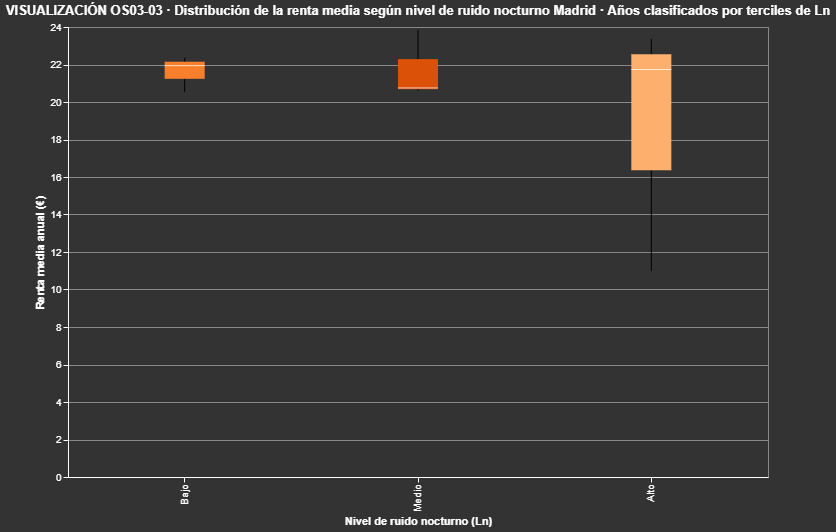

In [34]:
# =========================================================
# OS03‑03 · Renta media según nivel de ruido nocturno
# (Análisis temporal por años)
# =========================================================

os03_03_chart = (
    alt.Chart(df_os03_03)
    .mark_boxplot(size=40)
    .encode(
        x=alt.X(
            "nivel_ruido:N",
            title="Nivel de ruido nocturno (Ln)",
            sort=["Bajo", "Medio", "Alto"]
        ),
        y=alt.Y(
            "renta_media:Q",
            title="Renta media anual (€)"
        ),
        color=alt.Color(
            "nivel_ruido:N",
            scale=alt.Scale(scheme="oranges"),
            legend=None
        ),
        tooltip=[
            alt.Tooltip("nivel_ruido:N", title="Nivel de ruido"),
            alt.Tooltip("renta_media:Q", title="Renta media (€)", format=",.0f")
        ]
    )
    .properties(
        width=700,
        height=450,
        title=(
            "VISUALIZACIÓN OS03‑03 · Distribución de la renta media según nivel de ruido nocturno\n"
            "Madrid · Años clasificados por terciles de Ln"
        )
    )
)

os03_03_chart

La visualización OS03‑03 compara la distribución de la renta media anual en Madrid entre distintos niveles de ruido nocturno, definidos a partir de la clasificación de los años en terciles según el valor medio de Ln. 

El boxplot permite identificar diferencias en la mediana y la dispersión de la renta asociadas a periodos de mayor o menor exposición acústica, complementando el análisis temporal y de asociación continua del OS03.

### VISUALIZACIÓN OS03‑04 · Evolución conjunta de ruido, renta y normativa

OBJETIVO: Contextualizar la relación entre prosperidad económica y ruido nocturno frente a los umbrales normativos de salud pública.
Mostrar cuándo el ruido nocturno supera el umbral normativo. Ver si esos periodos coinciden con:
* Mayor renta
* estancamiento
* o divergencia entre prosperidad y calidad ambiental

TIPO DE GRÁFICO: Línea temporal + línea de referencia normativa

Justificación: 
* Integra el componente normativo (salud pública).
* Permite analizar la hipótesis relativa a causalidad en los periodos de mayor prosperidad coinciden con superación de límites acústicos.

Datos utilizados:
* df_02_cont_acustic → Ln anual
* df_09_renta → renta_media, periodo (año)
* df_03_noise_lim → umbral Ln nocturno (50db), indicador Ln

PREPARACIÓN DE DATOS

In [35]:
# 3.1 Ruido nocturno medio anual
df_ruido_anual = (
    df_02_cont_acustic
    .dropna(subset=["ln"])
    .groupby("year", as_index=False)
    .agg(
        ln_medio=("ln", "mean")
    )
)

df_ruido_anual.head()

,year,ln_medio
0,2015,57.257097
1,2016,57.769086
2,2017,57.706486
3,2018,57.444355
4,2019,57.098922


In [36]:
# 3.2 Renta media anual (Madrid)
df_renta_anual = (
    df_09_renta
    .groupby("periodo", as_index=False)
    .agg(
        renta_media=("renta_media", "mean")
    )
    .rename(columns={"periodo": "year"})
)

df_renta_anual.head()

,year,renta_media
0,2015,23.825265
1,2016,23.359292
2,2017,10.984895
3,2018,21.733797
4,2019,20.749759


In [38]:
# 3.3 Dataset integrado OS03‑04
#columnas finales: year, renta_media, ln_medio
df_os03_04 = (
    df_renta_anual
    .merge(df_ruido_anual, on="year", how="inner")
)

df_os03_04.head()

,year,renta_media,ln_medio
0,2015,23.825265,57.257097
1,2016,23.359292,57.769086
2,2017,10.984895,57.706486
3,2018,21.733797,57.444355
4,2019,20.749759,57.098922


In [39]:
# 3.4 Umbral normativo Ln nocturno
#Extraemos el valor (suele ser 50 dB):
limite_ln = (
    df_03_noise_lim
    .query("noiselevelindicator == 'lnight'")
    ["limitvalue"]
    .iloc[0]
)
limite_ln

np.float64(50.0)

La visualización OS03‑04 integra la evolución de la renta media y del ruido nocturno en Madrid con el umbral normativo de referencia para el indicador Ln. 

Esta comparación permite contextualizar la relación entre prosperidad económica y exposición acústica desde una perspectiva de salud pública, identificando periodos en los que el crecimiento económico coexiste con la superación de límites sonoros recomendados.

* Se utilizan dos gráficos alineados verticalmente con mismo eje X (años)
* * Gráfico superior → Ruido nocturno + límite normativo (50 dB)
* * Gráfico inferior → Renta media
Ambos sincronizados por año, e interactivos.
Se evita ambigüedad de escalas.

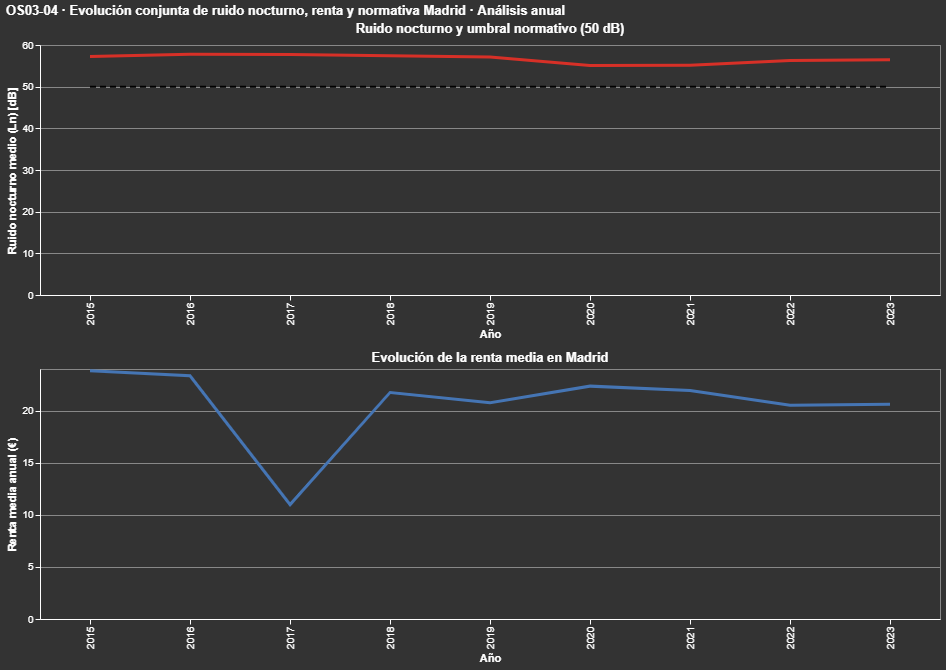

In [44]:

# =========================================================
# OS03‑04 · Evolución conjunta de ruido, renta y normativa
# (VERSIÓN CORRECTA – sin error de vconcat)
# =========================================================

# -----------------------
# Gráfico 1 · Ruido nocturno + límite normativo
# -----------------------

df_limite = pd.DataFrame({
    "year": df_os03_04["year"],
    "limite_ln": [limite_ln] * len(df_os03_04)
})

ruido_chart = (
    alt.Chart(df_os03_04)
    .mark_line(color="#d73027", strokeWidth=3)
    .encode(
        x=alt.X("year:O", title="Año"),
        y=alt.Y(
            "ln_medio:Q",
            title="Ruido nocturno medio (Ln) [dB]"
        ),
        tooltip=[
            alt.Tooltip("year:O", title="Año"),
            alt.Tooltip("ln_medio:Q", title="Ln medio [dB]", format=".2f")
        ]
    )
    +
    alt.Chart(df_limite)
    .mark_line(
        color="black",
        strokeDash=[6, 4],
        strokeWidth=2
    )
    .encode(
        x="year:O",
        y="limite_ln:Q"
    )
).properties(
    width=900,          # ✅ width aquí
    height=250,
    title="Ruido nocturno y umbral normativo (50 dB)"
)

# -----------------------
# Gráfico 2 · Renta media
# -----------------------

renta_chart = (
    alt.Chart(df_os03_04)
    .mark_line(color="#4575b4", strokeWidth=3)
    .encode(
        x=alt.X("year:O", title="Año"),
        y=alt.Y(
            "renta_media:Q",
            title="Renta media anual (€)"
        ),
        tooltip=[
            alt.Tooltip("year:O", title="Año"),
            alt.Tooltip("renta_media:Q", title="Renta media (€)", format=",.0f")
        ]
    )
).properties(
    width=900,          # ✅ width aquí
    height=250,
    title="Evolución de la renta media en Madrid"
)

# -----------------------
# Visualización conjunta FINAL
# -----------------------

os03_04_chart = (
    alt.vconcat(
        ruido_chart,
        renta_chart,
        spacing=10
    )
    .interactive()
    .properties(
        title=(
            "OS03‑04 · Evolución conjunta de ruido nocturno, renta y normativa\n"
            "Madrid · Análisis anual"
        )
    )
)

os03_04_chart

El conjunto OS03 queda coherente y sólido:

OS03‑01 → evolución temporal

OS03‑02 → asociación ruido–renta

OS03‑03 → comparación distributiva por niveles de ruido

OS03‑04 → contexto normativo y lectura crítica

El conjunto de visualizaciones del OS03 ha permitido analizar de forma integrada la relación entre prosperidad económica y exposición al ruido nocturno en Madrid desde una perspectiva temporal, estadística y contextual. 

La OS03‑01 ha mostrado la evolución conjunta de la renta media y del ruido nocturno, evidenciando tendencias que no siempre convergen y sugieren una desconexión parcial entre crecimiento económico y mejora de la calidad acústica. 

La OS03‑02 ha profundizado en esta relación mediante un análisis de asociación anual, donde la dispersión de los datos y la línea de tendencia indican una correlación débil, descartando una relación lineal simple entre renta y niveles de ruido. 

La OS03‑03, al comparar la distribución de la renta entre periodos clasificados por niveles de ruido, ha permitido observar diferencias en mediana y dispersión, reforzando la idea de que la exposición acústica no se distribuye de manera aleatoria respecto a la prosperidad económica. 

Finalmente, la OS03‑04 ha incorporado el contexto normativo, mostrando que varios periodos con mayor renta coinciden con la superación del umbral nocturno recomendado, lo que subraya una tensión persistente entre desarrollo económico y sostenibilidad ambiental. 

En conjunto, las visualizaciones confirman la hipótesis de que la prosperidad no garantiza una reducción de la exposición al ruido y refuerzan la necesidad de integrar criterios de salud ambiental en las políticas de desarrollo urbano.



In [45]:
%whos

Variable                          Type            Data/Info
-----------------------------------------------------------
KaggleDatasetAdapter              EnumType        <enum 'KaggleDatasetAdapter'>
PCA                               ABCMeta         <class 'sklearn.decomposition._pca.PCA'>
StandardScaler                    type            <class 'sklearn.preproces<...>ng._data.StandardScaler'>
alt                               module          <module 'altair' from 'C:<...>es\\altair\\__init__.py'>
dataframe_columns                 function        <function dataframe_colum<...>ns at 0x000001AAEC49FEC0>
dataframe_hash                    function        <function dataframe_hash at 0x000001AAEB8F4AE0>
df_01_daily                       DataFrame       Shape: (17772, 3)
df_01_daily_plot                  DataFrame       Shape: (131045, 3)
df_01_ruido_diario                DataFrame       Shape: (521356, 17)
df_02_cont_acustic                DataFrame       Shape: (9389, 17)
df_02_estac       